
===== GEOMETRY CHECK =====
Outer diameter = 25.1 mm
Inner diameter = 11.3 mm
Cross-section area = 3.945212e-04 m² (394.52 mm²)

===== RESULTS =====
Applied force = 50000 N
Max stress = 126.74 MPa
Total shortening = 3802.08 µm (3.802 mm)



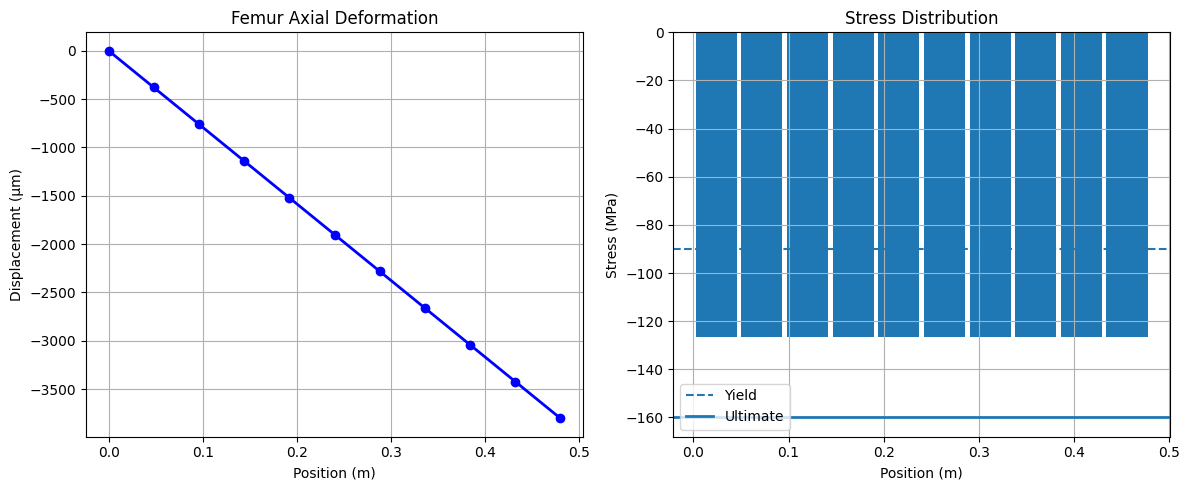

Plot saved as femur_fea.png


In [2]:
import numpy as np
import math
from scipy.linalg import solve
import matplotlib.pyplot as plt

# =========================================================
# FEMUR GEOMETRY (SI UNITS ONLY)
# =========================================================
length = 0.48                     # meters

outer_diameter_mm = 25.1          # mm (from SolidWorks)
inner_diameter_mm = 11.3          # mm

# Convert to meters
outer_diameter = outer_diameter_mm / 1000
inner_diameter = inner_diameter_mm / 1000

outer_radius = outer_diameter / 2
inner_radius = inner_diameter / 2

# Hollow circular cross-section
area = math.pi * (outer_radius**2 - inner_radius**2)

print("\n===== GEOMETRY CHECK =====")
print(f"Outer diameter = {outer_diameter_mm} mm")
print(f"Inner diameter = {inner_diameter_mm} mm")
print(f"Cross-section area = {area:.6e} m² ({area*1e6:.2f} mm²)")
print("==========================\n")

# =========================================================
# MATERIAL PROPERTIES (CORTICAL BONE)
# =========================================================
E = 16e9                          # Young's modulus (Pa)

yield_strength = 90               # MPa
ultimate_strength = 160           # MPa

# =========================================================
# LOADING
# =========================================================
force = -50000                    # Newton (compression)

# =========================================================
# MESH
# =========================================================
n_elements = 10
L_e = length / n_elements
n_nodes = n_elements + 1

# =========================================================
# GLOBAL STIFFNESS MATRIX
# =========================================================
K = np.zeros((n_nodes, n_nodes))

k_local = (area * E) / L_e

for i in range(n_elements):
    K[i,i] += k_local
    K[i+1,i+1] += k_local
    K[i,i+1] -= k_local
    K[i+1,i] -= k_local

# =========================================================
# BOUNDARY CONDITIONS
# =========================================================
K_reduced = K[1:, 1:]
F = np.zeros(n_nodes - 1)
F[-1] = force

# Solve system
u_reduced = solve(K_reduced, F)

u = np.zeros(n_nodes)
u[1:] = u_reduced

# =========================================================
# STRESS & STRAIN
# =========================================================
stresses = []
strains = []

for i in range(n_elements):
    strain = (u[i+1] - u[i]) / L_e
    stress = E * strain
    strains.append(strain)
    stresses.append(stress)

stresses_mpa = np.array(stresses) / 1e6
max_stress = np.max(np.abs(stresses_mpa))

total_shortening = abs(u[-1])

# =========================================================
# FAILURE CHECK
# =========================================================
print("===== RESULTS =====")
print(f"Applied force = {abs(force)} N")
print(f"Max stress = {max_stress:.2f} MPa")
print(f"Total shortening = {total_shortening*1e6:.2f} µm ({total_shortening*1e3:.3f} mm)")

if max_stress > ultimate_strength:
    print("FRACTURE: Ultimate strength exceeded")
elif max_stress > yield_strength:
    print("WARNING: Yield exceeded → Plastic deformation")
else:
    print("Elastic behaviour → No fracture")

print("===================\n")

# =========================================================
# PLOTS
# =========================================================
x = np.linspace(0, length, n_nodes)

plt.figure(figsize=(12,5))

# Displacement
plt.subplot(1,2,1)
plt.plot(x, u*1e6, 'bo-', linewidth=2)
plt.xlabel("Position (m)")
plt.ylabel("Displacement (µm)")
plt.title("Femur Axial Deformation")
plt.grid()

# Stress
centers = x[:-1] + L_e/2

plt.subplot(1,2,2)
plt.bar(centers, stresses_mpa, width=L_e*0.9)
plt.axhline(-yield_strength, linestyle='--', label="Yield")
plt.axhline(-ultimate_strength, linewidth=2, label="Ultimate")
plt.xlabel("Position (m)")
plt.ylabel("Stress (MPa)")
plt.title("Stress Distribution")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("femur_fea.png", dpi=300)
plt.show()

print("Plot saved as femur_fea.png")
